In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('placement_predict_50k_adjusted.csv')

print("Dataset loaded successfully!")
print(df.head())
print("Shape:", df.shape)

Dataset loaded successfully!
   StudentID  Gender       City  CollegeTier            Stream  \
0          1    Male  Bangalore            2        Mechanical   
1          2  Female  Bangalore            2             Civil   
2          3    Male  Hyderabad            1  Computer Science   
3          4    Male    Chennai            2        Mechanical   
4          5    Male     Mumbai            1       Electronics   

    Specialisation Hostel HistoryOfBacklogs ExtraCurricular  CGPA  \
0     Data Science     No               Yes              No  7.20   
1  Web Development    Yes                No              No  5.05   
2               ML     No                No              No  7.51   
3   Cyber Security    Yes               Yes              No  7.38   
4               ML    Yes               Yes             Yes  6.49   

   AptitudeScore  CodingScore  CommunicationScore  Internships  Projects  \
0           90.6         34.9                79.9          2.0         4   
1      

In [3]:
df = df.drop(columns=['IsAnomaly'])

print("IsAnomaly column removed.")
print(df.head())

IsAnomaly column removed.
   StudentID  Gender       City  CollegeTier            Stream  \
0          1    Male  Bangalore            2        Mechanical   
1          2  Female  Bangalore            2             Civil   
2          3    Male  Hyderabad            1  Computer Science   
3          4    Male    Chennai            2        Mechanical   
4          5    Male     Mumbai            1       Electronics   

    Specialisation Hostel HistoryOfBacklogs ExtraCurricular  CGPA  \
0     Data Science     No               Yes              No  7.20   
1  Web Development    Yes                No              No  5.05   
2               ML     No                No              No  7.51   
3   Cyber Security    Yes               Yes              No  7.38   
4               ML    Yes               Yes             Yes  6.49   

   AptitudeScore  CodingScore  CommunicationScore  Internships  Projects  \
0           90.6         34.9                79.9          2.0         4   
1         

In [4]:
for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully.")
print(df.isnull().sum())

Missing values handled successfully.
StudentID             0
Gender                0
City                  0
CollegeTier           0
Stream                0
Specialisation        0
Hostel                0
HistoryOfBacklogs     0
ExtraCurricular       0
CGPA                  0
AptitudeScore         0
CodingScore           0
CommunicationScore    0
Internships           0
Projects              0
PlacementStatus       0
dtype: int64


In [5]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Gender',
        'City',
        'CollegeTier',
        'Stream',
        'Specialisation',
        'Hostel',
        'HistoryOfBacklogs',
        'ExtraCurricular'
    ],
    drop_first=True
)

print("Categorical columns encoded successfully.")
print(df_encoded.head())

Categorical columns encoded successfully.
   StudentID  CGPA  AptitudeScore  CodingScore  CommunicationScore  \
0          1  7.20           90.6         34.9                79.9   
1          2  5.05           33.0         78.0                75.5   
2          3  7.51           57.3         89.1                68.8   
3          4  7.38           46.5         90.4                61.0   
4          5  6.49           73.2         69.9                74.1   

   Internships  Projects  PlacementStatus  Gender_Male  City_Chennai  ...  \
0          2.0         4                1         True         False  ...   
1          2.0         5                0        False         False  ...   
2          1.0         4                1         True         False  ...   
3          0.0         3                0         True          True  ...   
4          1.0         0                0         True         False  ...   

   Stream_Computer Science  Stream_Electronics  Stream_Information Technol

In [6]:
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (50000, 23)
Target shape: (50000,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40000, 23)
Testing data: (10000, 23)


In [8]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [9]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[0 0 1 0 1 1 1 0 1 0 0 0 1 1 0 0 0 1 1 0]


In [10]:
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Decision Tree Accuracy: 0.7374
Accuracy Percentage: 73.74000000000001 %


In [11]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.75      0.74      4969
           1       0.75      0.72      0.73      5031

    accuracy                           0.74     10000
   macro avg       0.74      0.74      0.74     10000
weighted avg       0.74      0.74      0.74     10000



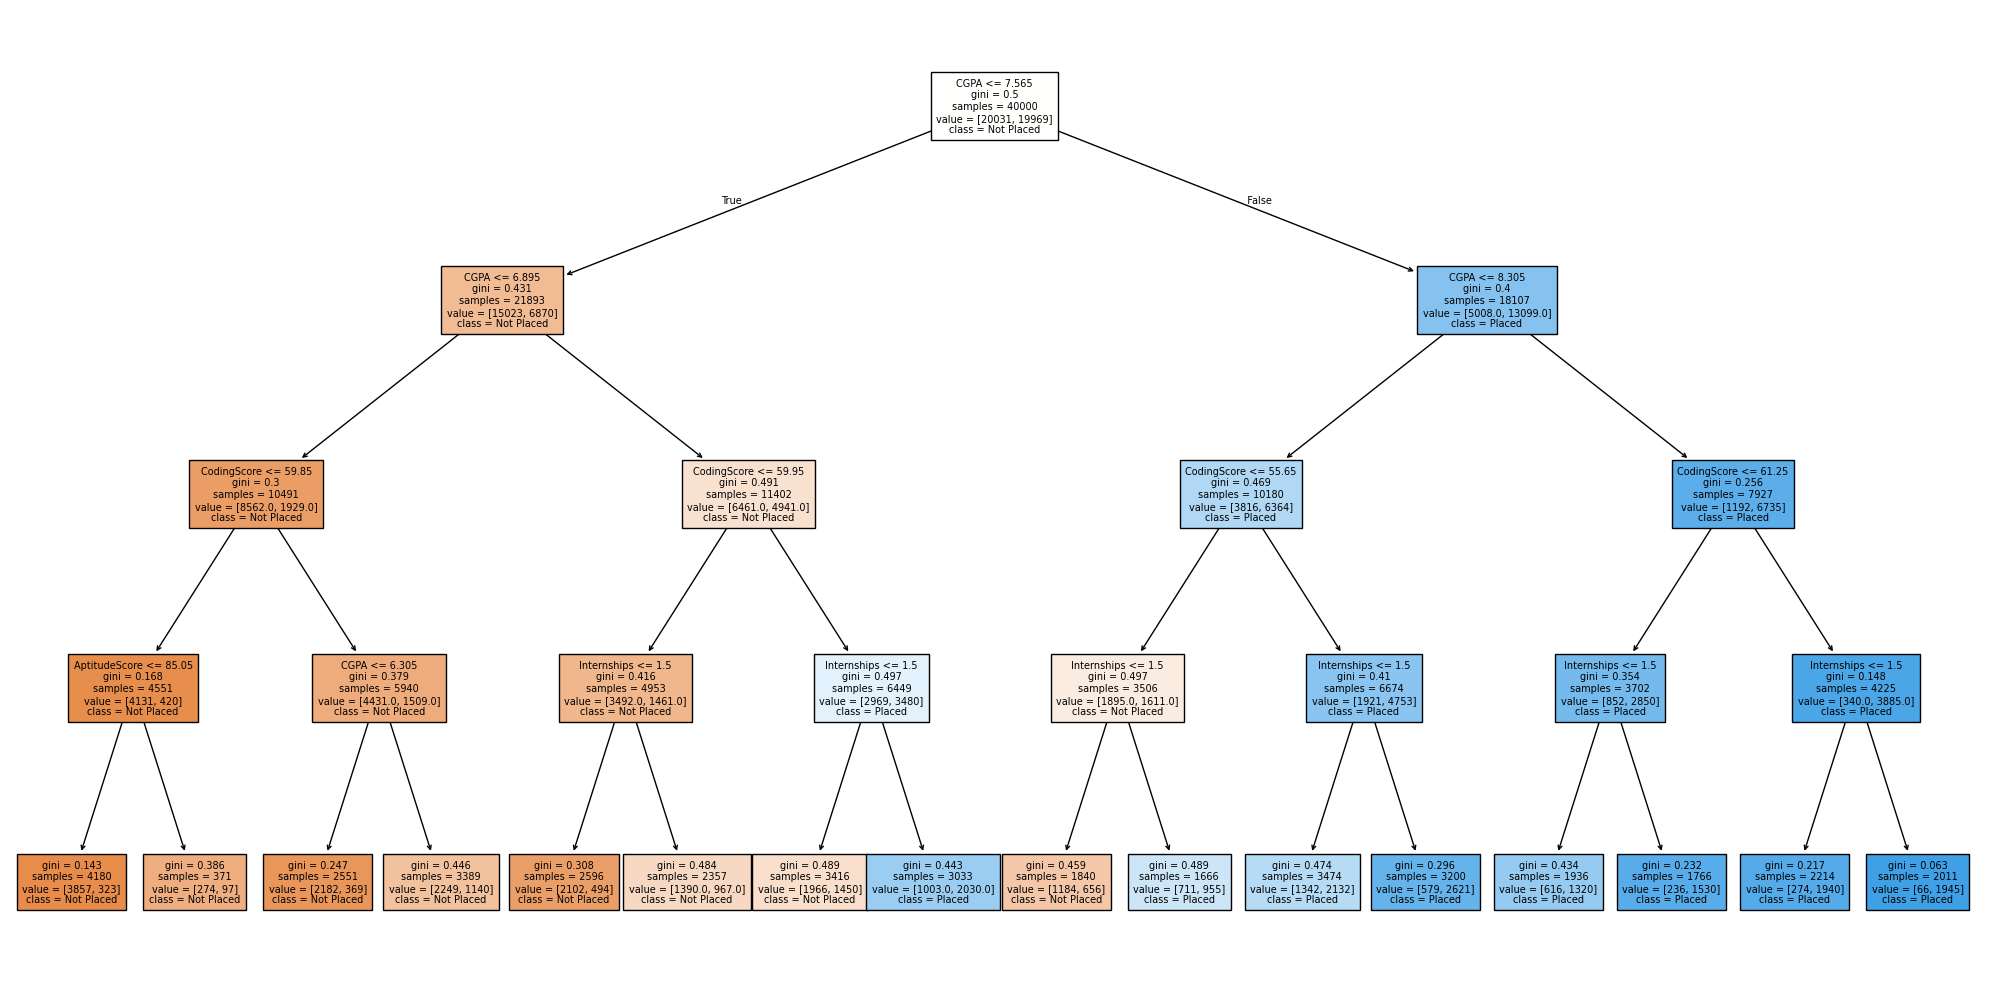

In [12]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.show()

Saved tree image.


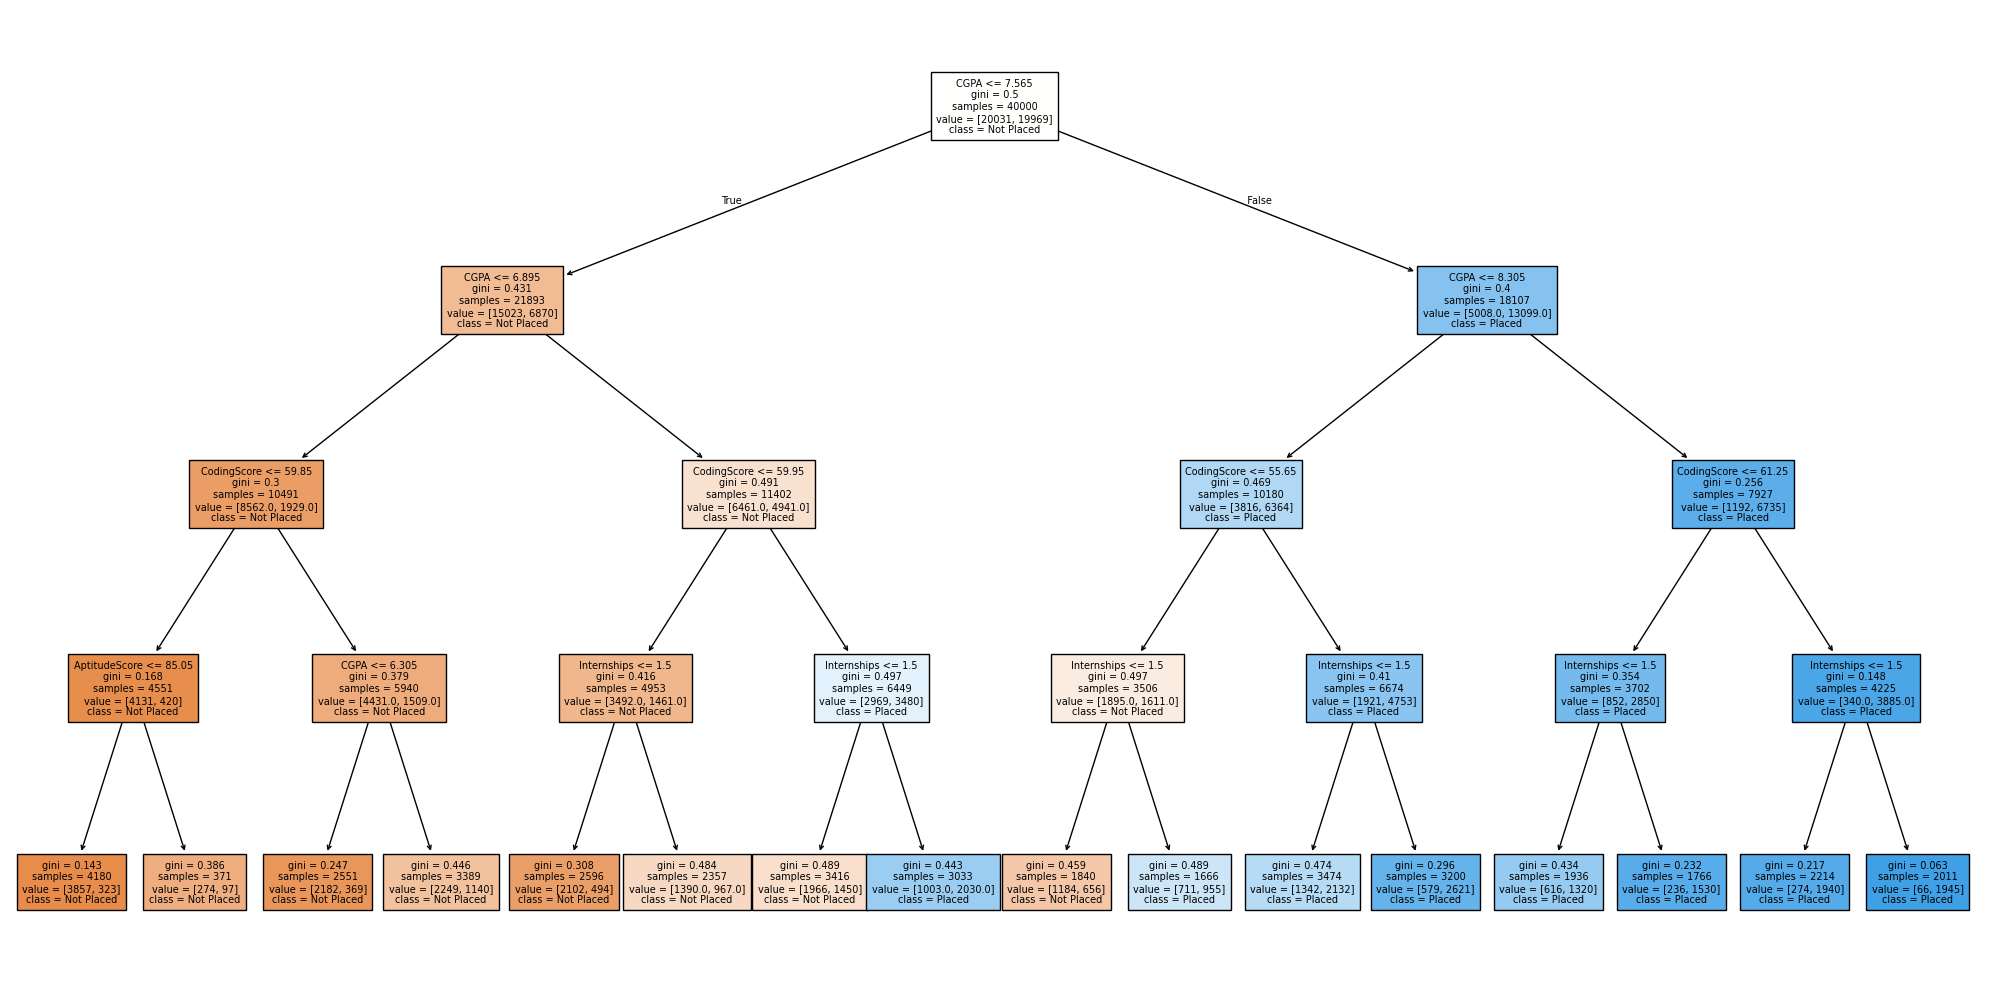

In [13]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7
)

plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)

print("Saved tree image.")

In [14]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [15]:
df = pd.read_csv("simple_placement_dataset.csv")

print("Sample of the dataset:")
print(df.head())

print("\nDataset shape:", df.shape)

print("\nClass balance:")
print(df['Placed'].value_counts())

Sample of the dataset:
   StudentID  CGPA  AptitudeScore  CodingScore  Internships  Projects  \
0          1  6.59           69.5         78.4            2         4   
1          2  9.04           63.6         71.8            0         2   
2          3  7.57           71.5         81.3            1         3   
3          4  7.52           42.2         46.2            2         3   
4          5  7.95           75.6         77.9            0         5   

   Attendance  Placed  
0        68.6       0  
1        73.2       0  
2        88.6       1  
3        72.9       0  
4        87.7       1  

Dataset shape: (1000, 8)

Class balance:
Placed
0    500
1    500
Name: count, dtype: int64


In [16]:
TARGET = "Placed"
DROP_COLS = ["StudentID"]

feature_names = [
    c for c in df.columns
    if c not in [TARGET] + DROP_COLS
]

X = df[feature_names].values
y = df[TARGET].values

print("Features:")
print(feature_names)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['CGPA', 'AptitudeScore', 'CodingScore', 'Internships', 'Projects', 'Attendance']

X shape: (1000, 6)
y shape: (1000,)


In [17]:
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 6)
Testing data: (200, 6)


In [18]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features="sqrt",
    oob_score=True,
    random_state=RANDOM_STATE
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [19]:
rf.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [20]:
y_pred = rf.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[0 0 0 0 1 0 1 0 0 0 0 1 1 0 1 1 0 1 1 1]


In [21]:
test_accuracy = accuracy_score(y_test, y_pred)

print("OOB Score:", rf.oob_score_)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100, "%")

OOB Score: 0.82125
Test Accuracy: 0.835
Test Accuracy Percentage: 83.5 %


In [22]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.85       107
           1       0.83      0.82      0.82        93

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.83      0.83      0.83       200



In [23]:
print("Feature Importances:")

for name, importance in sorted(
    zip(feature_names, rf.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"{name}: {importance:.4f}")

Feature Importances:
CGPA: 0.4085
CodingScore: 0.1904
AptitudeScore: 0.1463
Attendance: 0.1145
Projects: 0.0792
Internships: 0.0612


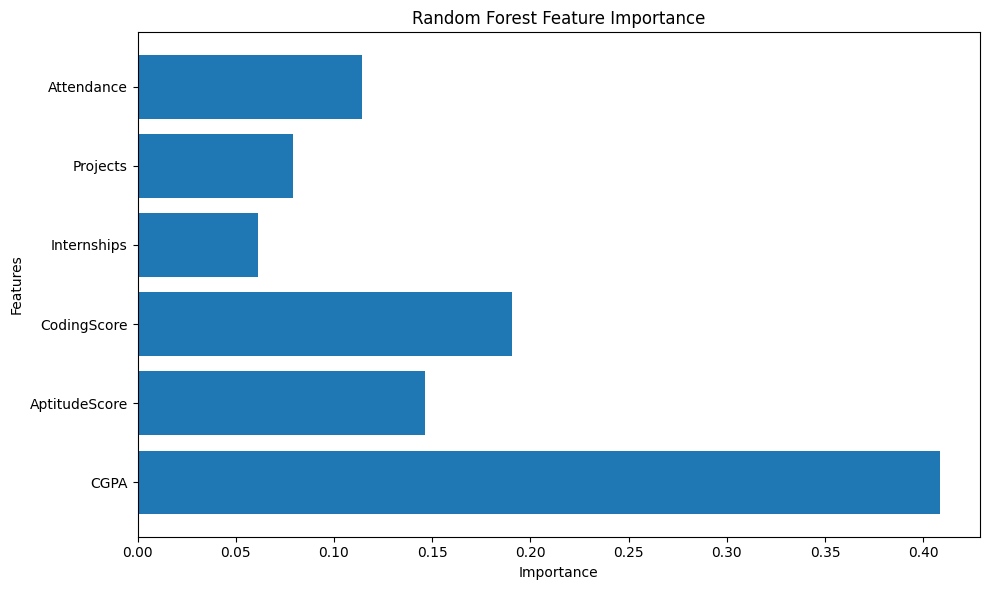

In [24]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_

plt.figure(figsize=(10, 6))

plt.barh(feature_names, importances)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()